# 04 - Calibración, umbral y evaluación

Toma el modelo seleccionado en el notebook anterior (**XGBoost**, indistinguible de LightGBM dentro del piso de ruido medido en el 03) y lo convierte en un sistema de decisión que maximiza la ganancia:

1. **Calibración** de las probabilidades (para que el umbral económico sea válido).
2. **Umbral** que maximiza la ganancia, elegido en validación.
3. **Evaluación en test**: ganancia vs. baselines, matriz de confusión en casos y en pesos, y concentración del valor por monto.
4. **Interpretabilidad** (SHAP) y ablación de la variable más importante.

In [1]:
import sys
sys.path.append("..")
%load_ext autoreload
%autoreload 2

# --- Librerías de terceros ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import xgboost as xgb_lib
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import (brier_score_loss, average_precision_score,
                             precision_score, recall_score, f1_score)

# --- Código del proyecto (src/) ---
from src.data import load_raw, clean
from src.features import (temporal_split, build_preprocessor,
                          NUM_FEATURES, CAT_LOW, CAT_HIGH)
from src.model import build_xgb, BEST_XGB_PARAMS
from src import utils
from src.utils import PALETA
from src.profit import (find_best_threshold, profit_from_threshold,
                        BREAK_EVEN_THRESHOLD, total_profit, approve_all_profit,
                        reject_all_profit, max_possible_profit, captured_margin, transaction_value)


utils.set_style()
RANDOM_STATE = 42

# Cargar, limpiar y partir
df = clean(load_raw("../data/dataset.csv"))
train, val, test = temporal_split(df, train_frac=0.7, val_frac=0.15)

FEATURES = NUM_FEATURES + CAT_LOW + CAT_HIGH
X_train, y_train = train[FEATURES], train["fraude"]
X_val,   y_val   = val[FEATURES],   val["fraude"]
X_test,  y_test  = test[FEATURES],  test["fraude"]

monto_val  = val["monto"].values
monto_test = test["monto"].values

spw = (y_train == 0).sum() / (y_train == 1).sum()
xgb = build_xgb(scale_pos_weight=spw, params=BEST_XGB_PARAMS)
xgb.fit(X_train, y_train)


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['b', 'c', 'd', 'e', 'f', 'h',
                                                   'l', 'm', 'monto',
                                                   'score']),
                                                 ('cat_low',
                                                  Pipeline(steps=[('imput',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='infrequent_if_exist',
                                                                                 min_frequency=0.01,
                                                                                 sparse_output=False))]),
                                                  ['a', 'g', 'n', 'o', 'p']),...
                               gamma=2.601477385704998, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.0286642261344634, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=4,
                               max_leaves=None, min_child_weight=5, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=664, n_jobs=1,
                               num_parallel_tree=None, ...))])

## Calibración de probabilidades

### Diagnóstico

El umbral de decisión económico (0,20) se aplica sobre las probabilidades del
modelo, así que estas tienen que ser **reales**: cuando el modelo dice 0,20,
debe haber ~20% de fraude. Pero XGBoost, al usar `scale_pos_weight` para
compensar el desbalance, produce probabilidades **sobreestimadas**. Calibrar corrige el *valor* de las probabilidades sin cambiar el ordenamiento
del modelo, por lo que el PR-AUC no se altera.

El *reliability diagram* compara la probabilidad predicha (eje X) con la
fracción real de fraude (eje Y). La calibración perfecta cae sobre la diagonal.

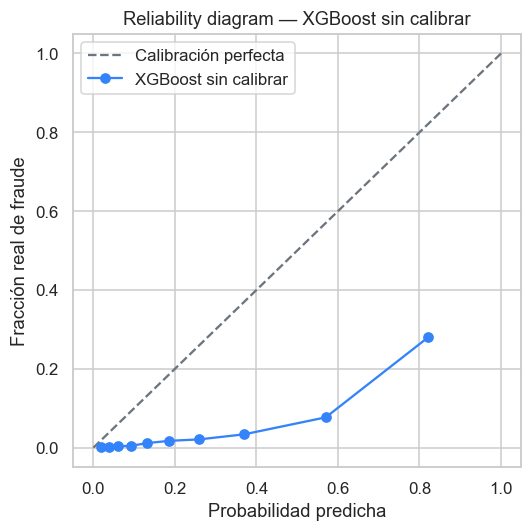

Brier score (sin calibrar): 0.1108


In [2]:
p_val = xgb.predict_proba(X_val)[:, 1]
frac_real, prob_pred = calibration_curve(y_val, p_val, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], "--", color=PALETA["neutro"], label="Calibración perfecta")
ax.plot(prob_pred, frac_real, "o-", color=PALETA["principal"], label="XGBoost sin calibrar")
ax.set_xlabel("Probabilidad predicha")
ax.set_ylabel("Fracción real de fraude")
ax.set_title("Reliability diagram — XGBoost sin calibrar")
ax.legend()
plt.tight_layout()
plt.show()

print("Brier score (sin calibrar):", round(brier_score_loss(y_val, p_val), 4))

La curva cae claramente **por debajo de la diagonal**: el modelo sobreestima el
fraude. El Brier score sin
calibrar es 0,11. 

### Calibración

Se aprende una **función correctora** que mapea el score
crudo del modelo a una probabilidad real. Se ajusta sobre validación, usando
los pares (score predicho, resultado real): aprende "cuando el modelo dice X,
la tasa real de fraude es Y". 

Se comparan dos métodos:

- **Sigmoid (Platt):** asume que la corrección tiene forma de curva S (dos
  parámetros). Simple y robusto con pocos datos, pero limitado a esa forma.
- **Isotonic:** ajusta una función escalonada **monótona no decreciente** (a
  mayor score, mayor o igual probabilidad, nunca menor). De forma libre, se
  adapta a distorsiones más complejas, pero necesita más datos.

Platt (estrictamente creciente) preserva exactamente el ranking, por lo que el
PR-AUC no cambia. Isotonic, en cambio, puede introducir empates que lo alteran
levemente.


In [3]:
# Comparar los dos métodos en Brier (calibración) Y PR-AUC (ranking)
for metodo in ["sigmoid", "isotonic"]:
    cal = CalibratedClassifierCV(xgb, method=metodo, cv="prefit").fit(X_val, y_val)
    p = cal.predict_proba(X_val)[:, 1]
    print(f"{metodo:9} → Brier: {brier_score_loss(y_val, p):.4f} | "
          f"PR-AUC: {average_precision_score(y_val, p):.4f}")

print(f"{'sin cal.':9} → Brier: {brier_score_loss(y_val, p_val):.4f} | "
      f"PR-AUC: {average_precision_score(y_val, p_val):.4f}")

# Se elige Platt (sigmoid): preserva el ranking. 
xgb_cal = CalibratedClassifierCV(xgb, method="sigmoid", cv="prefit").fit(X_val, y_val)
p_val_cal = xgb_cal.predict_proba(X_val)[:, 1]

sigmoid   → Brier: 0.0339 | PR-AUC: 0.4428
isotonic  → Brier: 0.0321 | PR-AUC: 0.4339
sin cal.  → Brier: 0.1108 | PR-AUC: 0.4428


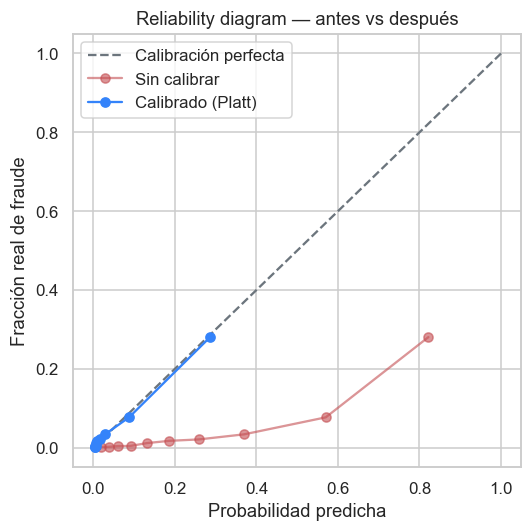

In [4]:
frac_c, prob_c = calibration_curve(y_val, p_val_cal, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], "--", color=PALETA["neutro"], label="Calibración perfecta")
ax.plot(prob_pred, frac_real, "o-", color="#C44E52", alpha=0.6, label="Sin calibrar")
ax.plot(prob_c, frac_c, "o-", color=PALETA["principal"], label="Calibrado (Platt)")
ax.set_xlabel("Probabilidad predicha")
ax.set_ylabel("Fracción real de fraude")
ax.set_title("Reliability diagram — antes vs después")
ax.legend()
plt.tight_layout()
plt.show()

Se comparan sigmoid (Platt) e isotonic en dos ejes: calidad de las
probabilidades (Brier) e impacto en el ranking (PR-AUC).

| Método | Brier (val) | PR-AUC (val) |
|--------|-------------|--------------|
| Sin calibrar | 0,110 | 0,442 |
| **Sigmoid (Platt)** | 0,034 | 0,442 |
| Isotonic | 0,032 | 0,433 |

Isotonic da un Brier levemente menor, pero **degrada el PR-AUC** (0,442 → 0,433):
al ser monótona no estrictamente creciente, genera empates que reducen el
Average Precision. Platt es estrictamente creciente, **preserva el ranking**
(0,442, idéntico al sin calibrar) y calibra con calidad equivalente. Como el
modelo se seleccionó por PR-AUC, se elige **Platt**.

## Umbral de ganancia

Con las probabilidades ya calibradas, se busca el umbral de decisión que
**maximiza la ganancia** sobre validación, usando la función de `profit.py`.
El umbral se elige en validación (nunca en test) para no sesgar la evaluación.

In [5]:
mejor_umbral, mejor_ganancia, grid, ganancias = find_best_threshold(
    y_val, monto_val, p_val_cal
)

print(f"Umbral óptimo (val): {mejor_umbral:.2f}")
print(f"Ganancia con umbral óptimo:  ${mejor_ganancia:,.0f}")
print(f"Ganancia con umbral 0.20:    "
      f"${profit_from_threshold(y_val, monto_val, p_val_cal, BREAK_EVEN_THRESHOLD):,.0f}")

Umbral óptimo (val): 0.21
Ganancia con umbral óptimo:  $170,006
Ganancia con umbral 0.20:    $169,751


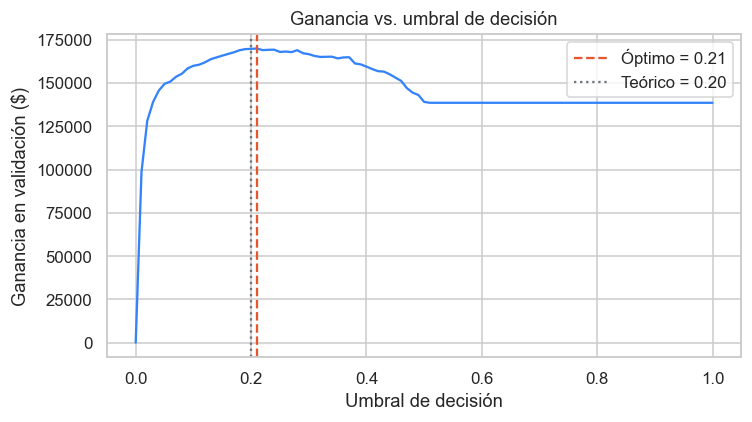

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(grid, ganancias, color=PALETA["principal"])
ax.axvline(mejor_umbral, color=PALETA["acento"], ls="--", label=f"Óptimo = {mejor_umbral:.2f}")
ax.axvline(BREAK_EVEN_THRESHOLD, color=PALETA["neutro"], ls=":", label="Teórico = 0.20")
ax.set_xlabel("Umbral de decisión")
ax.set_ylabel("Ganancia en validación ($)")
ax.set_title("Ganancia vs. umbral de decisión")
ax.legend()
plt.tight_layout()
plt.show()

## Evaluación

In [7]:
p_test_cal = xgb_cal.predict_proba(X_test)[:, 1]

# Decisión: aprobar si p <= umbral; rechazar (= predecir fraude) si p > umbral
aprobar = p_test_cal <= mejor_umbral
pred_fraude = ~aprobar

ganancia_modelo = total_profit(y_test, monto_test, aprobar)
maximo = max_possible_profit(y_test, monto_test)
aprobar_todo = approve_all_profit(y_test, monto_test)

print(f"=== Evaluación final en TEST (umbral {mejor_umbral:.2f}) ===")
print(f"Modelo:          ${ganancia_modelo:,.0f}")
print(f"Aprobar todo:    ${aprobar_todo:,.0f}")
print(f"Rechazar todo:   ${reject_all_profit(y_test, monto_test):,.0f}")
print(f"Máximo posible:  ${maximo:,.0f}")
print(f"\nCaptura {ganancia_modelo/maximo*100:.1f}% del máximo posible")
print(f"Mejora sobre 'aprobar todo': ${ganancia_modelo - aprobar_todo:,.0f}")

print(f"\n--- Clasificación en el umbral {mejor_umbral:.2f} ---")
print(f"Precision (fraude): {precision_score(y_test, pred_fraude):.3f}")
print(f"Recall (fraude):    {recall_score(y_test, pred_fraude):.3f}")
print(f"F1 (fraude):        {f1_score(y_test, pred_fraude):.3f}")

=== Evaluación final en TEST (umbral 0.21) ===
Modelo:          $173,489
Aprobar todo:    $138,456
Rechazar todo:   $0
Máximo posible:  $217,836

Captura 79.6% del máximo posible
Mejora sobre 'aprobar todo': $35,032

--- Clasificación en el umbral 0.21 ---
Precision (fraude): 0.349
Recall (fraude):    0.557
F1 (fraude):        0.429


### Baseline basado en el score provisto en el dataset.

In [8]:
# Su umbral se optimiza en validación con la misma función de ganancia utilizada para seleccionar el umbral del modelo.
# Se asume que valores mayores de score representan mayor riesgo de fraude, según lo identificado en el análisis exploratorio.
score_val  = val["score"].values / 100    # score 0-100 → escala 0-1
score_test = test["score"].values / 100

umbral_score, _, _, _ = find_best_threshold(y_val, val["monto"].values, score_val)

# Se aprueban las transacciones cuyo riesgo estimado está por debajo o igual al umbral seleccionado.
aprobar_score = score_test <= umbral_score

ganancia_score = total_profit(y_test, monto_test, aprobar_score)

print(f"Score actual — umbral óptimo (val): {umbral_score:.2f}")
print(f"Score actual — ganancia (test):     ${ganancia_score:,.0f}")
print(f"Modelo — ganancia (test):           ${ganancia_modelo:,.0f}")
print(f"Mejora del modelo sobre el score:   ${ganancia_modelo - ganancia_score:,.0f}")

Score actual — umbral óptimo (val): 0.85
Score actual — ganancia (test):     $159,514
Modelo — ganancia (test):           $173,489
Mejora del modelo sobre el score:   $13,975


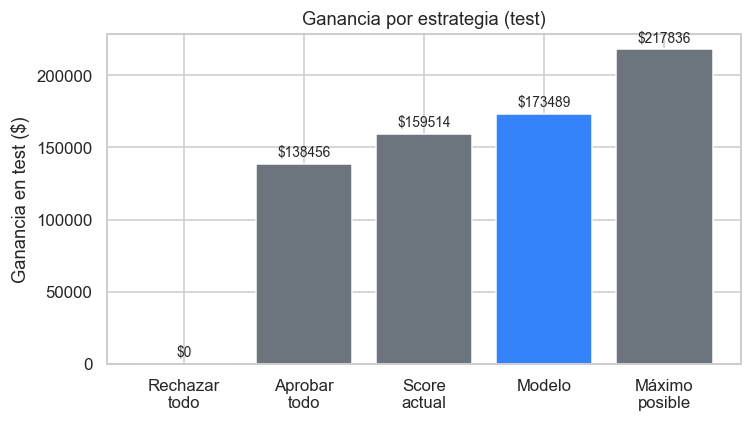

In [9]:
opciones = {
    "Rechazar\ntodo": reject_all_profit(y_test, monto_test),
    "Aprobar\ntodo": aprobar_todo,
    "Score\nactual": ganancia_score,
    "Modelo": ganancia_modelo,
    "Máximo\nposible": maximo,
}
nombres, valores = list(opciones), list(opciones.values())
colores = [PALETA["principal"] if n == "Modelo" else PALETA["neutro"] for n in nombres]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(nombres, valores, color=colores)
ax.bar_label(ax.containers[0], fmt="$%.0f", padding=3, fontsize=9)
ax.set_ylabel("Ganancia en test ($)")
ax.set_title("Ganancia por estrategia (test)")
plt.tight_layout()
plt.show()

### Resultados en test

Se aplica al test el umbral elegido en validación (0,21), sin re-optimizar.

| Estrategia | Ganancia (test) | Margen capturado |
|------------|-----------------|------------------|
| Rechazar todo | $0 | — |
| Aprobar todo | $138.456 | 0% |
| Score actual (sistema preexistente) | $159.514 | 26,5% |
| **Modelo (XGBoost)** | **$173.489** | **44,1%** |
| Máximo posible (oráculo) | $217.836 | 100% |

El modelo captura el **79,6%** del máximo posible (equivalente al **44,1%** de la brecha entre "aprobar todo" y el oráculo), supera a "aprobar todo" en **$35.033** y al sistema de score preexistente en **~$13.975**.

Métricas de clasificación en el umbral 0,21: precision 0,35, recall 0,56, F1 0,43. El recall moderado es **intencional**: el objetivo es maximizar la ganancia, no la detección — bajar el umbral atraparía más fraudes pero rechazaría más legítimas, reduciendo la ganancia neta.

In [10]:
# ganancia del modelo con el umbral elegido en validación
profit_modelo = profit_from_threshold(y_test, monto_test, p_test_cal, mejor_umbral)

margen = captured_margin(profit_modelo, y_test, monto_test)
print(f"Margen capturado (test): {margen:.1%}")

Margen capturado (test): 44.1%


In [11]:
filas = [
    ("Aprobar todo", aprobar_todo),
    ("Score actual", ganancia_score),
    ("Modelo (XGBoost)", ganancia_modelo),
    ("Oráculo (máximo)", maximo),
]

print(f"{'Estrategia':<20}{'Ganancia':>14}{'Margen':>10}")
for nombre, g in filas:
    m = captured_margin(g, y_test, monto_test)
    print(f"{nombre:<20}${g:>12,.0f}{m:>9.1%}")

Estrategia                Ganancia    Margen
Aprobar todo        $     138,456     0.0%
Score actual        $     159,514    26.5%
Modelo (XGBoost)    $     173,489    44.1%
Oráculo (máximo)    $     217,836   100.0%


### Anatomía de las decisiones: casos vs. pesos

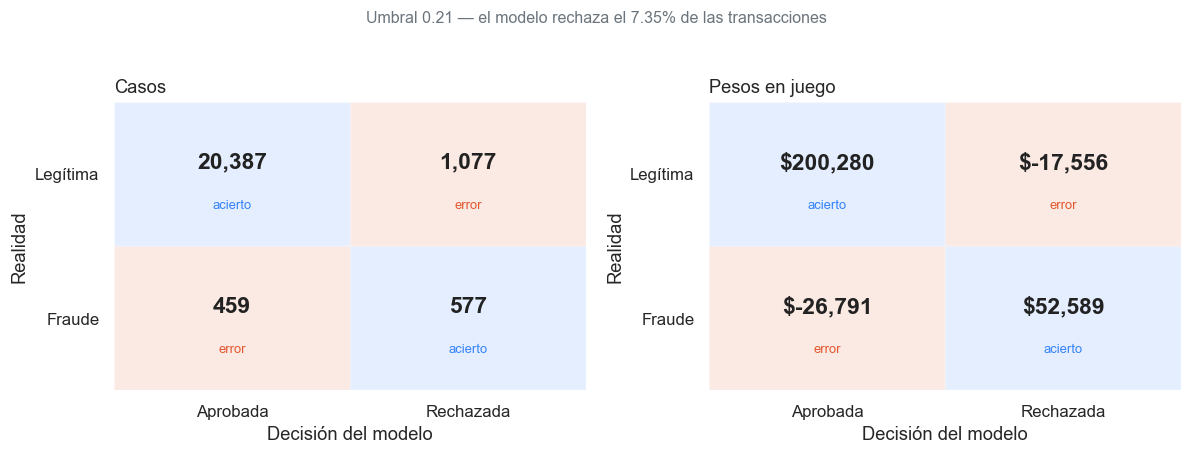

                          casos          pesos
legítima aprobada        20,387        200,280   ganados
legítima rechazada        1,077        -17,556   resignados
fraude aprobado             459        -26,791   perdidos
fraude frenado              577         52,589   evitados


In [12]:
from sklearn.metrics import confusion_matrix

y_arr  = np.asarray(y_test)
val_ap = transaction_value(y_arr, monto_test)   # valor de APROBAR cada fila
rechaza = p_test_cal > mejor_umbral             # rechazar = predecir fraude

cm = confusion_matrix(y_arr, rechaza.astype(int))
tn, fp, fn, tp = cm.ravel()

# La misma matriz, pero cada celda valorizada en pesos
dinero = np.array([[ val_ap[(y_arr == 0) & ~rechaza].sum(),    # TN: legítima aprobada (ganado)
                    -val_ap[(y_arr == 0) &  rechaza].sum()],   # FP: legítima rechazada (resignado)
                   [ val_ap[(y_arr == 1) & ~rechaza].sum(),    # FN: fraude aprobado (perdido)
                    -val_ap[(y_arr == 1) &  rechaza].sum()]])  # TP: fraude frenado (evitado)

acierto = np.array([[True, False], [False, True]])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, datos, titulo, fmt in [(axes[0], cm, "Casos", "{:,.0f}"),
                               (axes[1], dinero, "Pesos en juego", "${:,.0f}")]:
    for i in range(2):
        for j in range(2):
            ok = acierto[i, j]
            color = PALETA["principal"] if ok else PALETA["acento"]
            ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, facecolor=color,
                                       alpha=.13, edgecolor="white", linewidth=2))
            ax.text(j, i - .08, fmt.format(datos[i, j]), ha="center", va="center",
                    fontsize=15, fontweight="semibold", color="#222222")
            ax.text(j, i + .22, "acierto" if ok else "error", ha="center", va="center",
                    fontsize=8.5, color=color)
    ax.set_xlim(-.5, 1.5); ax.set_ylim(1.5, -.5)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Aprobada", "Rechazada"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Legítima", "Fraude"])
    ax.set_xlabel("Decisión del modelo"); ax.set_ylabel("Realidad")
    ax.set_title(titulo, loc="left"); ax.grid(False)
    for lado in ax.spines.values():
        lado.set_visible(False)
fig.suptitle(f"Umbral {mejor_umbral:.2f} — el modelo rechaza el {rechaza.mean():.2%} "
             f"de las transacciones", y=1.03, fontsize=10.5, color=PALETA["neutro"])
plt.tight_layout(); plt.show()

print(f"{'':22s} {'casos':>8s} {'pesos':>14s}")
print(f"{'legítima aprobada':22s} {tn:>8,} {dinero[0,0]:>14,.0f}   ganados")
print(f"{'legítima rechazada':22s} {fp:>8,} {dinero[0,1]:>14,.0f}   resignados")
print(f"{'fraude aprobado':22s} {fn:>8,} {dinero[1,0]:>14,.0f}   perdidos")
print(f"{'fraude frenado':22s} {tp:>8,} {dinero[1,1]:>14,.0f}   evitados")

- En conteo, el modelo rechaza más legítimas (1.077) de las que deja pasar
  fraudes (459). Pero en pesos la relación se invierte: los 459 fraudes que se
  escapan cuestan $26.791, más que los $17.556 resignados por las 1.077
  legítimas rechazadas.
- Las legítimas que rechaza son de **monto bajo** (solo $17.556 de margen
  resignado en 1.077 casos), mientras que los fraudes que frena son de **monto
  alto** ($52.589 evitados en 577 casos). El modelo aprende a rechazar donde el
  dinero está en juego y a equivocarse barato.
- La cuenta cierra: gana $52.589 frenando fraude, resigna $17.556 en fricción,
  neto **+$35.033 sobre aprobar todo** — exactamente la mejora reportada en test.

### Dónde se concentra el valor: por monto

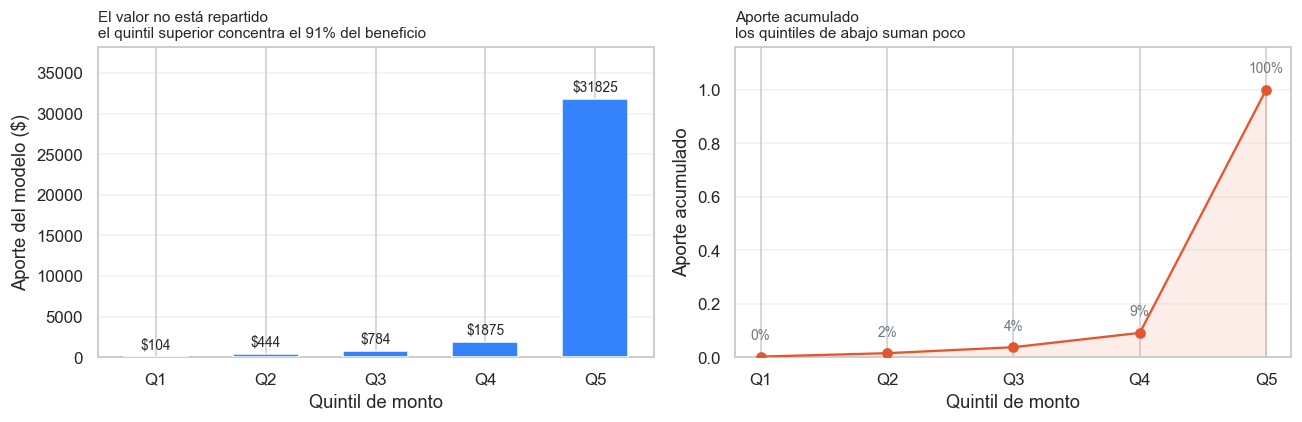

quintil    n  desde     hasta tasa_fraude rechazo  aporte captura aporte_pct
     Q1 4528  $0.02     $7.67       2.89%   3.75%    $104   0.149       0.3%
     Q2 4484  $7.68    $13.78       4.01%   5.78%    $444   0.239       1.3%
     Q3 4517 $13.79    $25.58       4.05%   6.82%    $784   0.222       2.2%
     Q4 4471 $25.59    $48.05       4.54%   7.49%  $1,875   0.261       5.4%
     Q5 4500 $48.08 $2,647.58       7.53%  12.93% $31,825   0.481      90.8%

El quintil superior aporta el 90.8% del beneficio con el 20% de las decisiones.
Habilita una política de dos niveles: no scorear por debajo de $48 costaría
el 9% del beneficio y ahorraría ~80% de las llamadas al modelo.


In [13]:
y_arr   = np.asarray(y_test)
val_ap  = transaction_value(y_arr, monto_test)
rechaza = p_test_cal > mejor_umbral

q = pd.qcut(monto_test, 5, labels=[f"Q{i}" for i in range(1, 6)])
seg = pd.DataFrame({"quintil": q, "y": y_arr, "monto": monto_test,
                    "rechaza": rechaza, "valor": val_ap})
filas = []
for nombre, g in seg.groupby("quintil", observed=True):
    piso_g  = g.valor.sum()             # aprobar todo, dentro del quintil
    techo_g = g.valor[g.y == 0].sum()   # oráculo, dentro del quintil
    mod_g   = g.valor[~g.rechaza].sum() # ganancia del modelo, dentro del quintil
    filas.append(dict(quintil=nombre, n=len(g), desde=g.monto.min(), hasta=g.monto.max(),
                      tasa_fraude=g.y.mean(), rechazo=g.rechaza.mean(),
                      aporte=mod_g - piso_g,
                      captura=(mod_g - piso_g) / (techo_g - piso_g)))
S = pd.DataFrame(filas)
S["aporte_pct"] = S.aporte / S.aporte.sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

barras = axes[0].bar(S.quintil, S.aporte, width=.6, color=PALETA["principal"], zorder=3)
axes[0].bar_label(barras, fmt="$%.0f", padding=3, fontsize=9)
axes[0].set_ylabel("Aporte del modelo ($)"); axes[0].set_xlabel("Quintil de monto")
axes[0].set_title(f"El valor no está repartido\n"
                  f"el quintil superior concentra el {S.aporte_pct.iloc[-1]:.0%} del beneficio",
                  loc="left", fontsize=10)
axes[0].margins(y=.20); axes[0].grid(axis="y", alpha=.3)

acum = S.aporte_pct.cumsum().values
axes[1].plot(S.quintil, acum, "o-", color=PALETA["acento"], zorder=3)
axes[1].fill_between(range(len(S)), 0, acum, color=PALETA["acento"], alpha=.10, zorder=2)
for x_, v in zip(range(len(S)), acum):
    axes[1].annotate(f"{v:.0%}", (x_, v), xytext=(0, 11), textcoords="offset points",
                     ha="center", fontsize=9, color=PALETA["neutro"])
axes[1].set_ylim(0, 1.16); axes[1].set_xlabel("Quintil de monto"); axes[1].set_ylabel("Aporte acumulado")
axes[1].set_title("Aporte acumulado\nlos quintiles de abajo suman poco", loc="left", fontsize=10)
axes[1].grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

print(S.to_string(index=False, formatters={
    "desde": "${:,.2f}".format, "hasta": "${:,.2f}".format,
    "tasa_fraude": "{:.2%}".format, "rechazo": "{:.2%}".format,
    "aporte": "${:,.0f}".format, "captura": "{:.3f}".format,
    "aporte_pct": "{:.1%}".format}))
print()
print(f"El quintil superior aporta el {S.aporte_pct.iloc[-1]:.1%} del beneficio con el 20% "
      f"de las decisiones.")
print(f"Habilita una política de dos niveles: no scorear por debajo de "
      f"${S.desde.iloc[-1]:,.0f} costaría")
print(f"el {1 - S.aporte_pct.iloc[-1]:.0%} del beneficio y ahorraría ~80% de las llamadas al modelo.")

El valor que genera el modelo está **fuertemente concentrado por monto**: el
quintil superior (el 20% de transacciones más grandes) aporta el **91%** del
beneficio, mientras que el 80% restante suma apenas el 9%. Es consecuencia
directa de la cola pesada de los montos: frenar un fraude caro vale más que
cientos de decisiones sobre transacciones pequeñas.

Esto habilita una **política de dos niveles** en producción: restringir el
modelo a las transacciones por encima del piso del quintil superior conserva
~91% del beneficio a cambio de solo el 20% de las llamadas al modelo; para
montos chicos, donde el error es barato, alcanza con el umbral teórico o una
regla simple. Es una decisión de despliegue —no de modelado— y refuerza que en
este problema lo que manda es el monto, no el conteo de casos.

## Interpretabilidad (SHAP)

Se usa SHAP (TreeExplainer) para medir la contribución de cada variable a las
predicciones del modelo. 

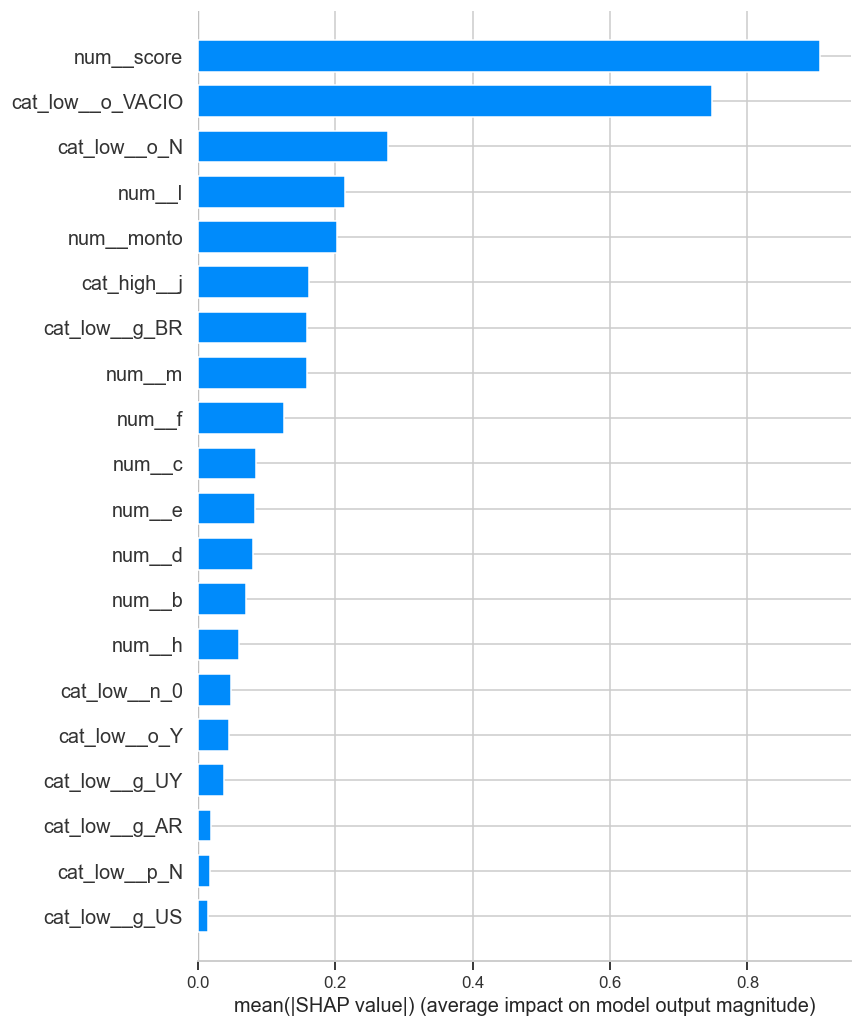

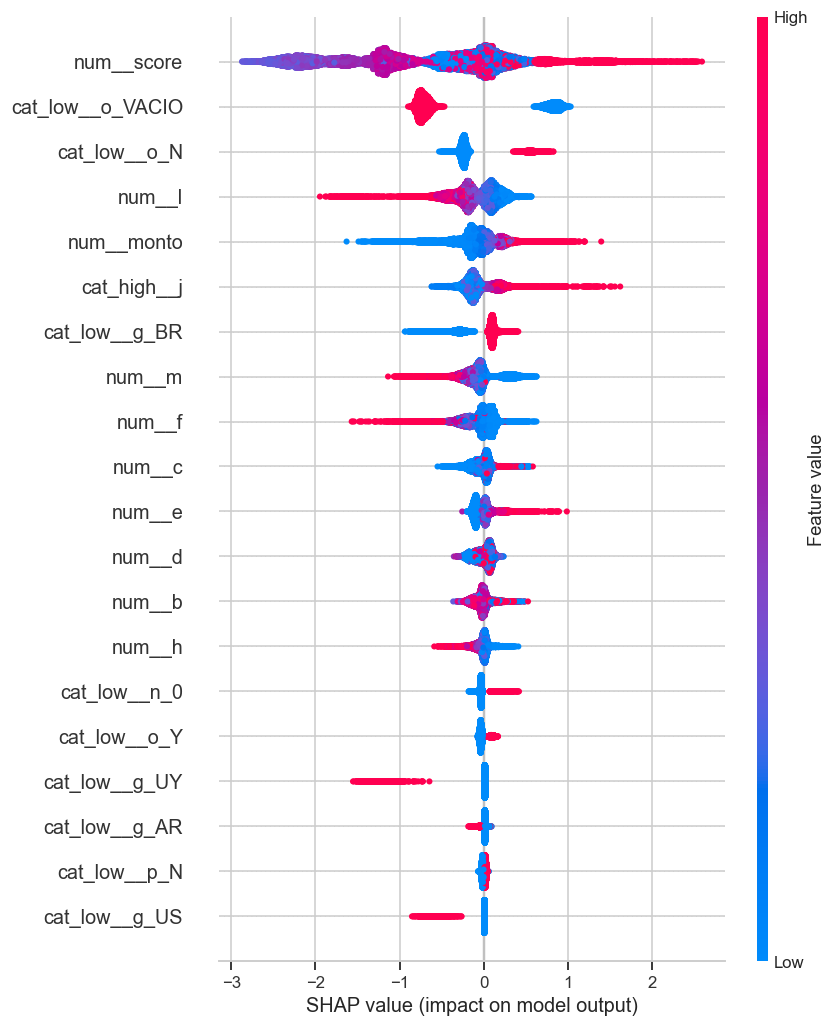

In [14]:
pre = xgb.named_steps["pre"]
clf = xgb.named_steps["clf"]

X_val_p = pre.transform(X_val)
feat_names = pre.get_feature_names_out()

# SHAP nativo de XGBoost (evita el problema de versiones de shap)
dval = xgb_lib.DMatrix(X_val_p)
contribs = clf.get_booster().predict(dval, pred_contribs=True)
shap_values = contribs[:, :-1]   # la última columna es el sesgo (bias), la quitamos

# Graficamos con shap (solo usamos su función de dibujo, no su explainer)
shap.summary_plot(shap_values, X_val_p, feature_names=feat_names,
                  plot_type="bar", show=True)
shap.summary_plot(shap_values, X_val_p, feature_names=feat_names, show=True)

SHAP confirma y refuerza los hallazgos del EDA:

- **`score`** es la variable más importante; valores altos empujan hacia fraude
  (coherente con ser el score de riesgo del sistema actual).
- **`o`** es la segunda en importancia: `o=VACIO` empuja hacia legítima y `o=N`
  hacia fraude. Valida la decisión de tratar el vacío como categoría propia
  (de haberlo descartado, se habría perdido una de las señales más fuertes).
- **`monto`** alto empuja hacia fraude; **`l`, `m`, `f`** muestran señal inversa
  (valores altos → legítima), coherente con el análisis bivariado.
- **`j`** (target encoding) y el país (BR hacia fraude, UY/US hacia legítima)
  aportan señal consistente con las tasas observadas.

La coincidencia entre EDA, bivariado y SHAP da robustez al análisis: la misma
historia surge desde tres enfoques distintos.

### Ablation: Contribución de score

In [15]:
# Modelo entrenado SIN la variable 'score'
num_sin = [c for c in NUM_FEATURES if c != "score"]
feat_sin = num_sin + CAT_LOW + CAT_HIGH

xgb_sin_score = Pipeline([
    ("pre", build_preprocessor(num=num_sin)),
    ("clf", XGBClassifier(**BEST_XGB_PARAMS, scale_pos_weight=spw,
                          eval_metric="aucpr", random_state=RANDOM_STATE, n_jobs=1)),
]).fit(train[feat_sin], y_train)

pr_con = average_precision_score(y_val, xgb.predict_proba(X_val)[:, 1])
pr_sin = average_precision_score(y_val, xgb_sin_score.predict_proba(val[feat_sin])[:, 1])
print(f"PR-AUC con score: {pr_con:.3f}")
print(f"PR-AUC sin score: {pr_sin:.3f}")

PR-AUC con score: 0.443
PR-AUC sin score: 0.354


### Ablation: contribución de `score`

Se entrena el modelo sin la variable `score` para medir cuánta señal aporta:

| Modelo | PR-AUC (val) |
|--------|--------------|
| Con `score` | 0,44 |
| Sin `score` | 0,34 |

`score` aporta señal sustancial: sin él, la PR-AUC cae de 0,44 a 0,34. Es
coherente con SHAP, donde `score` es la variable más importante. Refuerza la
condición de que el score debe estar disponible antes de la decisión: si no lo
estuviera, el modelo perdería una fracción relevante de su capacidad predictiva.